# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [6]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [9]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [11]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [13]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis England's Group Stage games

In [16]:
team = "England Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
14,3893794,England Women's,Haiti Women's,Group
15,3893794,Haiti Women's,England Women's,Group
48,3893811,Denmark Women's,England Women's,Group
49,3893811,England Women's,Denmark Women's,Group
82,3893828,China PR Women's,England Women's,Group
83,3893828,England Women's,China PR Women's,Group


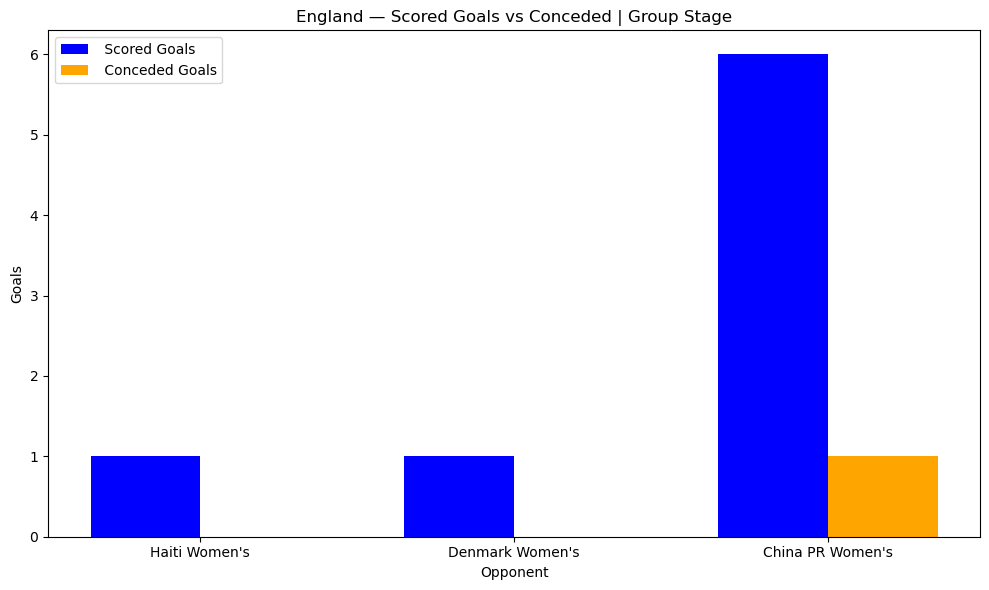

In [18]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart shown above, England won all three of its group stage matches, conceding only one goal to China. Despite this, it earned the highest number of points in the group stage: 9 points.

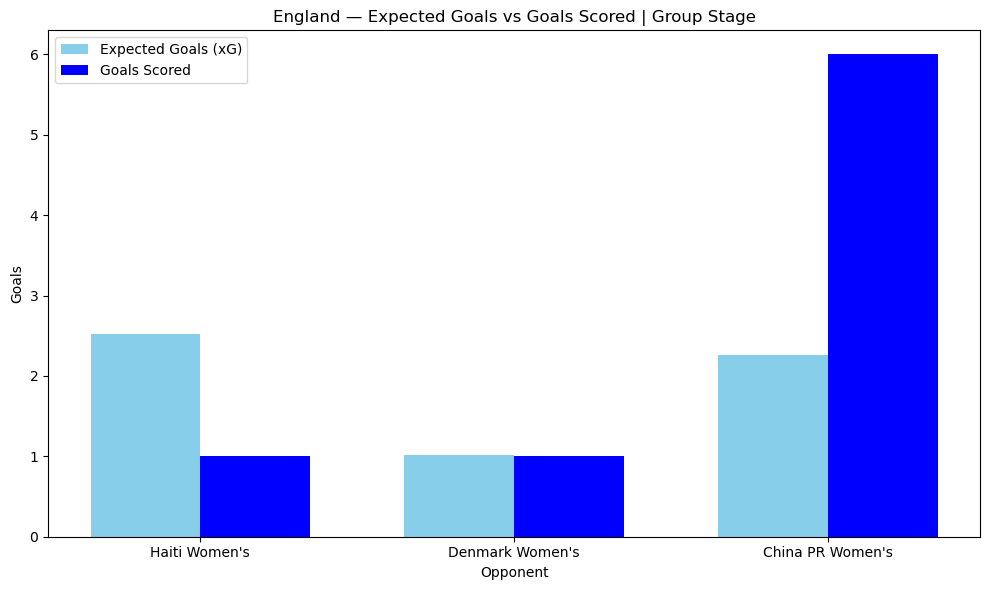

In [20]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

In the group stage, England’s performance was a bit unpredictable. By that I mean that the British team far exceeded expectations in terms of xG in their match against China; however, in the game against Haiti, one would have expected them to score more, but the team fell below expectations.

# Analysis of ENG-DEN

In [26]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Denmark": [
        match.loc[
            match["team"] == "Denmark Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Denmark"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Denmark"]
].round(1)


# Display table

comparison

,Metric,England,Denmark
0,Goals,1.0,0.0
1,xG,1.0,0.5
2,Goals Minus xG,-0.0,-0.5
3,Shots,12.0,6.0
4,Shots on Target,4.0,2.0
5,Saves,2.0,3.0
6,Possession %,65.2,34.8
7,Pass Accuracy %,83.7,61.8
8,Progressive Passes,159.0,70.0
9,Progressive Carries,26.0,14.0


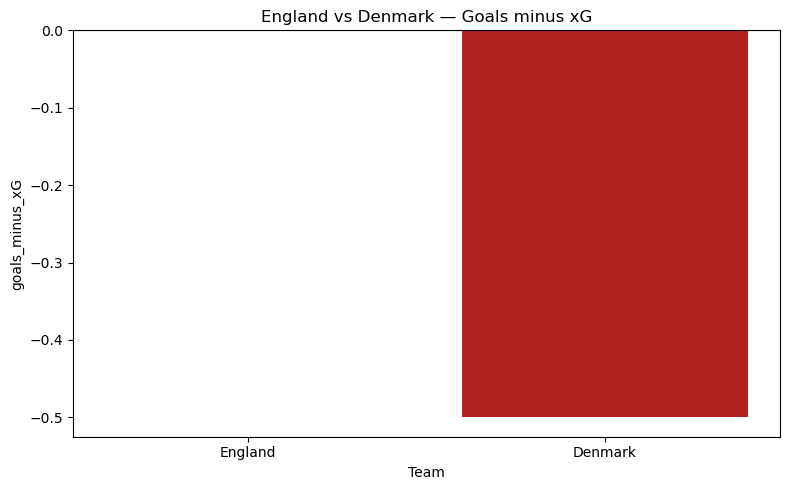

In [44]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


teams = ["England", "Denmark"]

goals_minus_xG = [
    match.loc[match["team"] == "England Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Denmark Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["navy", "firebrick"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("England vs Denmark — Goals minus xG")

plt.tight_layout()
plt.show()

England lived up to the xG prediction (1 goal), but Denmark slightly diminished that prediction, posting a worst outcome.

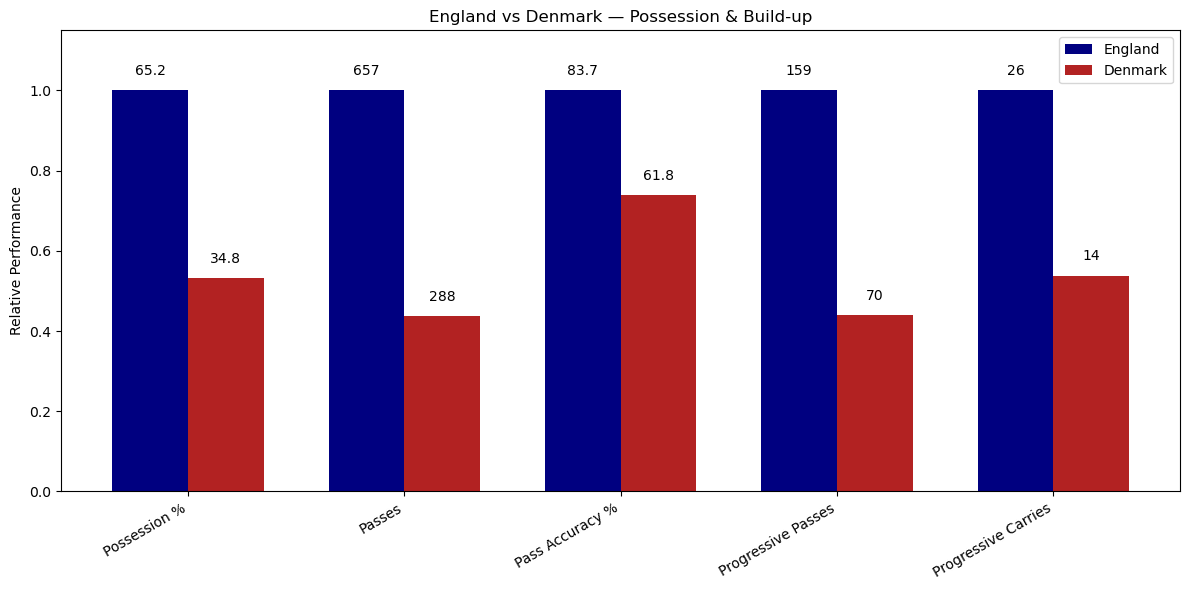

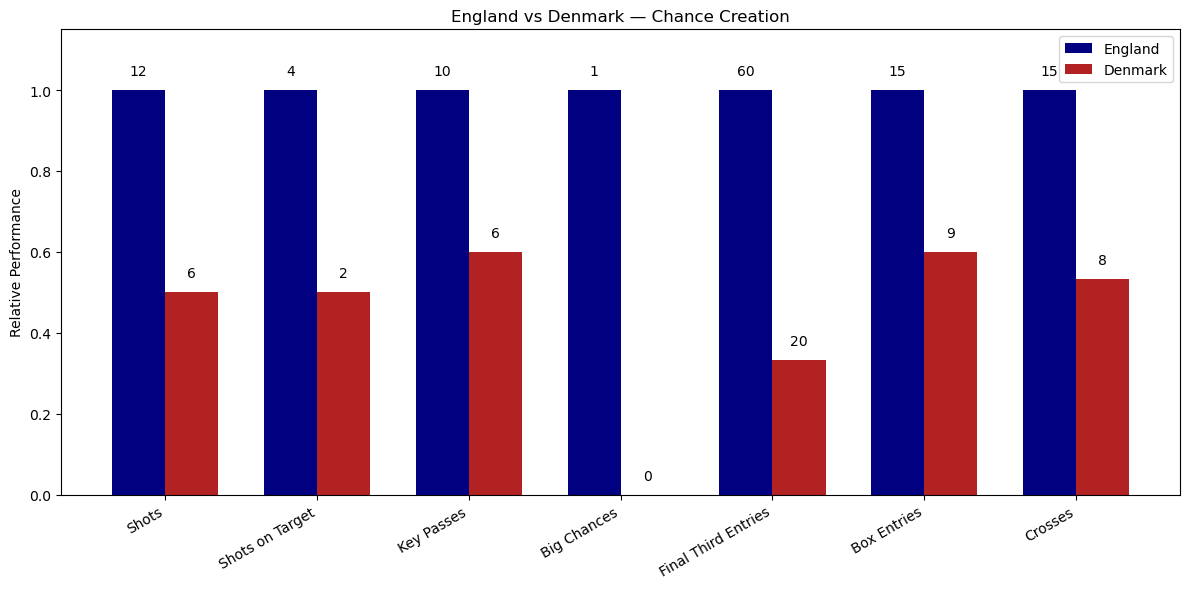

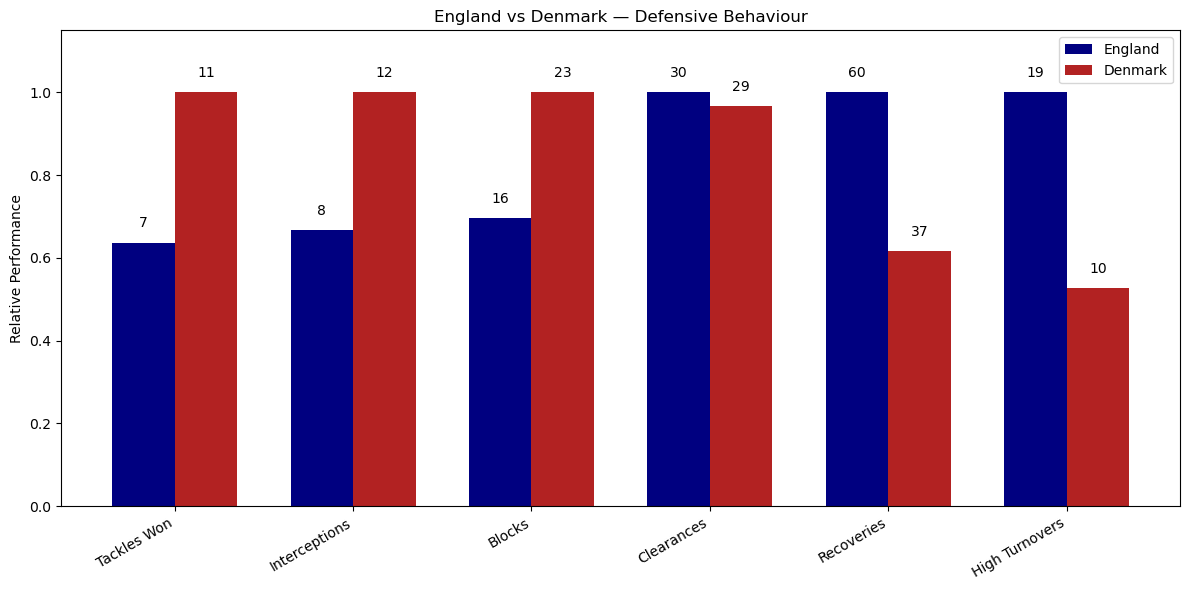

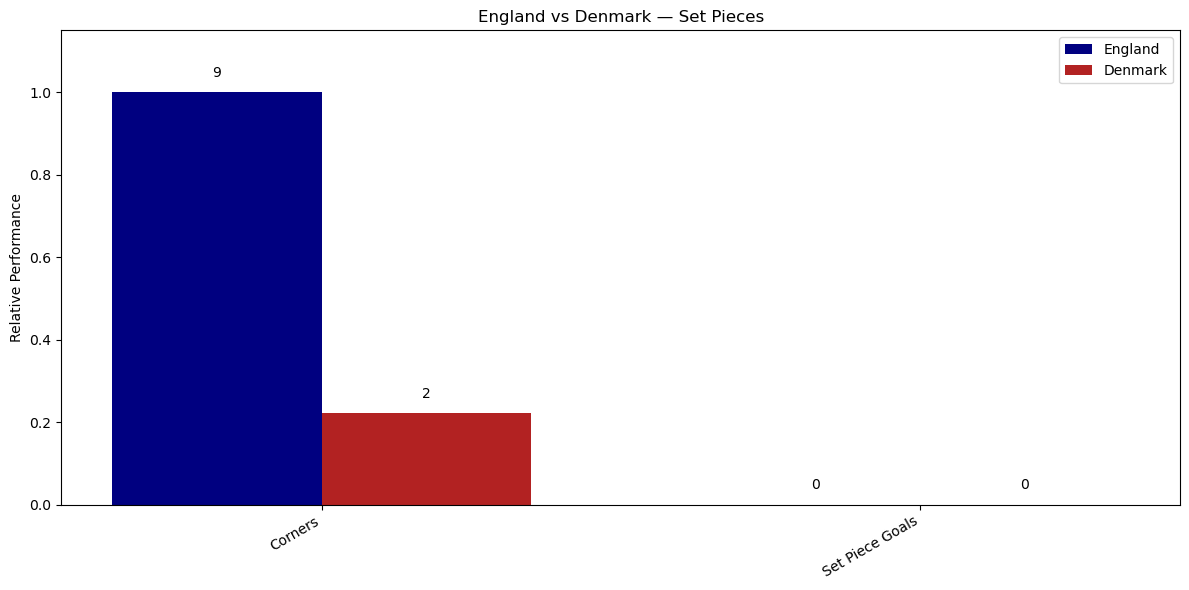

In [48]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "England": "England Women's",
    "Denmark": "Denmark Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    den_values = np.array([
        match.loc[
            match["team"] == team_names["Denmark"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(eng_values, den_values)

    # Normalize
    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )

    den_normalized = np.divide(
        den_values,
        max_values,
        out=np.zeros_like(den_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_eng = plt.bar(
        x - width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )

    bars_den = plt.bar(
        x + width / 2,
        den_normalized,
        width,
        label="Denmark",
        color="firebrick"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_eng, eng_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_den, den_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"England vs Denmark — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of ENG-DEN

England played a more attacking game. The metrics in the first two charts show the British team’s dominance over the Danes. The most notable figures are:
- pass accuracy: 83.7% - 61.8% 
- progressive carries: 159 - 70
- final third entries: 60-20
This suggests that play took place much more on Denmark’s side of the field and that they had little space to attack England. 

However, based on the metrics in the defensive chart, we can conclude that the Danish defense was very efficient, consistently creating space for blocks and saves. 

# Analysis of ENG-CHI

In [56]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "China": [
        match.loc[
            match["team"] == "China PR Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "China"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "China"]
].round(1)


# Display table

comparison

,Metric,England,China
0,Goals,6.0,1.0
1,xG,2.3,1.0
2,Goals Minus xG,3.7,-0.0
3,Shots,17.0,7.0
4,Shots on Target,7.0,3.0
5,Saves,2.0,1.0
6,Possession %,71.1,28.9
7,Pass Accuracy %,87.5,65.1
8,Progressive Passes,184.0,55.0
9,Progressive Carries,29.0,11.0


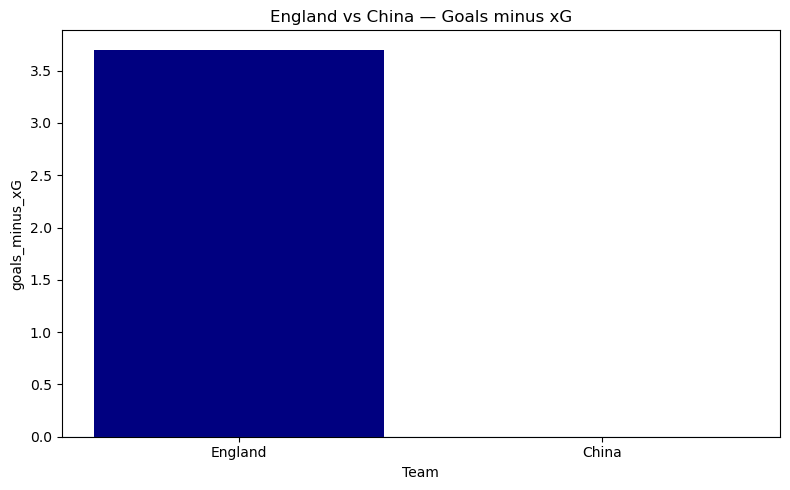

In [60]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


teams = ["England", "China"]

goals_minus_xG = [
    match.loc[match["team"] == "England Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "China PR Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["navy", "gold"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("England vs China — Goals minus xG")

plt.tight_layout()
plt.show()

China met its xG (1.0) by scoring 1 goal against England, but in contrast, the English team scored nearly 4 more goals than expected, securing a crushing victory. 

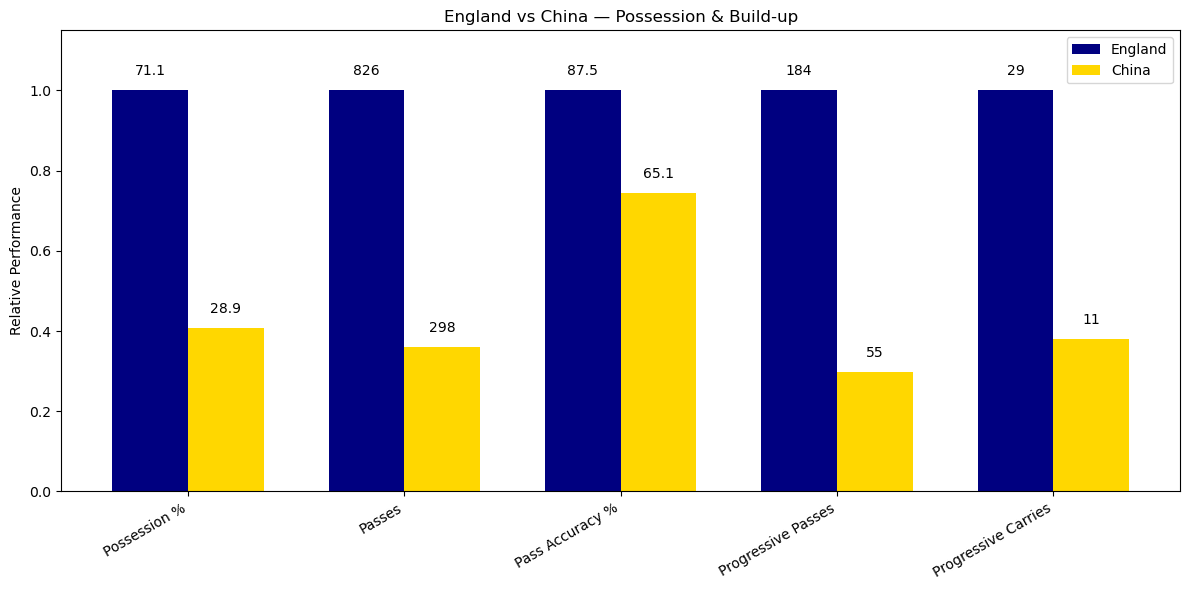

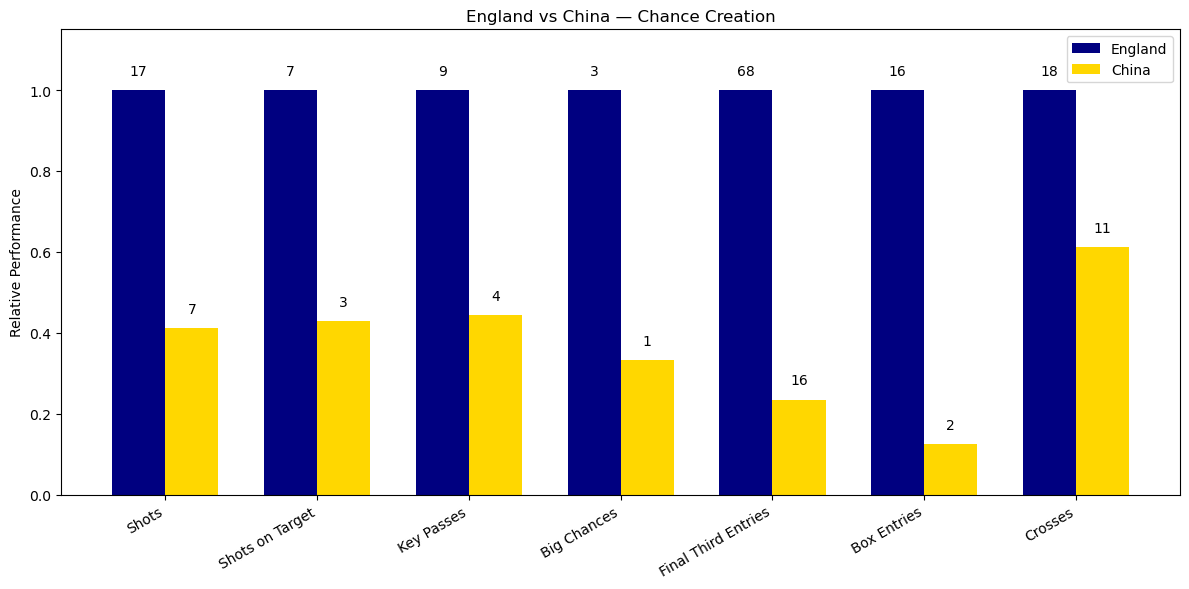

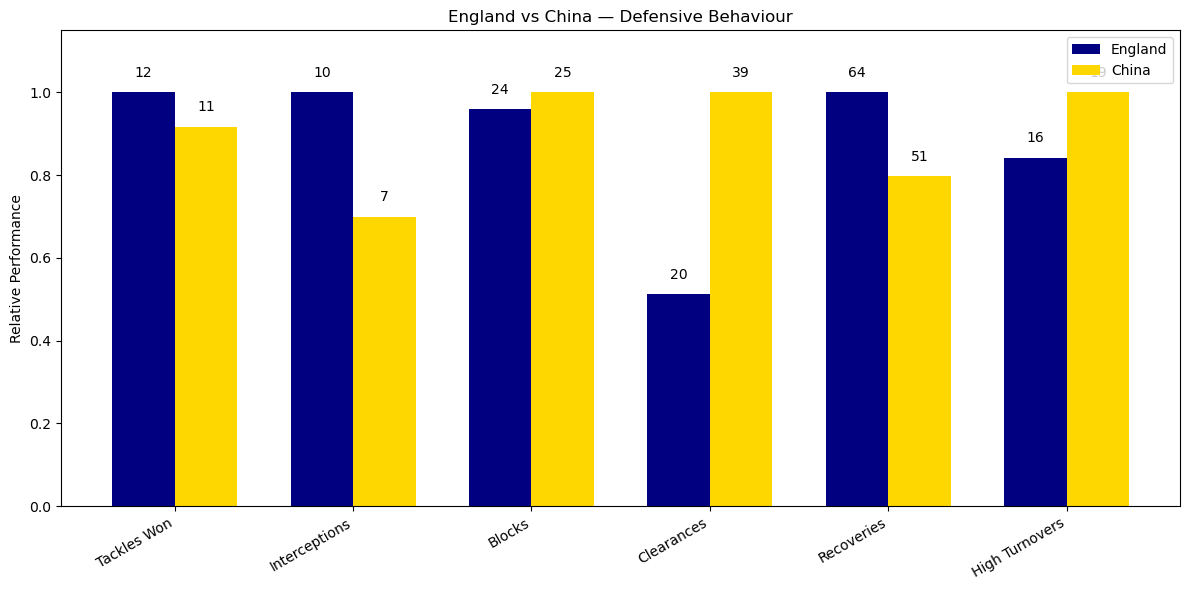

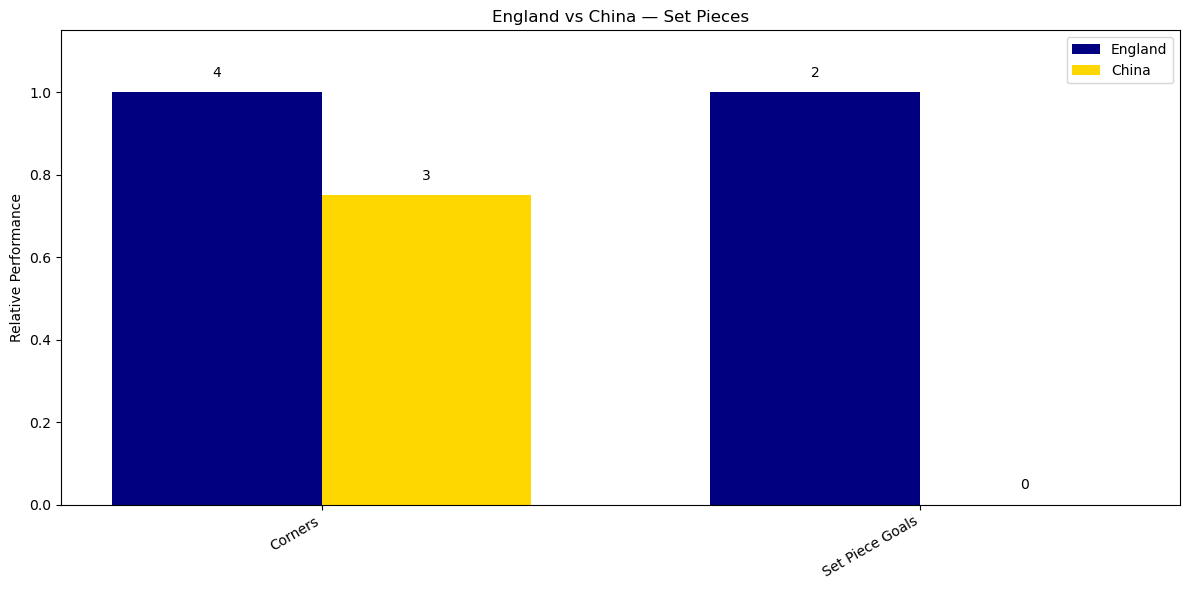

In [64]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "England": "England Women's",
    "China": "China PR Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    chi_values = np.array([
        match.loc[
            match["team"] == team_names["China"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(eng_values, chi_values)

    # Normalize
    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )

    chi_normalized = np.divide(
        chi_values,
        max_values,
        out=np.zeros_like(chi_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_eng = plt.bar(
        x - width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )

    bars_chi = plt.bar(
        x + width / 2,
        chi_normalized,
        width,
        label="China",
        color="gold"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_eng, eng_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_chi, chi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"England vs China — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of ENG-CHI

England's victory over China was overwhelming. The statistics suggest that, just as in the match against Denmark, the British team spent most of the game in the opponent's half, thus giving the defense room to adapt given the level of both teams.
China, despite everything, still managed to surprise with 7 shots, 1 of which resulted in a goal.

# Analysis of ENG-HAI

In [69]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Haiti": [
        match.loc[
            match["team"] == "Haiti Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Haiti"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Haiti"]
].round(1)


# Display table

comparison

,Metric,England,Haiti
0,Goals,1.0,0.0
1,xG,2.5,0.6
2,Goals Minus xG,-1.5,-0.6
3,Shots,20.0,7.0
4,Shots on Target,11.0,2.0
5,Saves,2.0,10.0
6,Possession %,65.9,34.1
7,Pass Accuracy %,85.0,57.3
8,Progressive Passes,157.0,75.0
9,Progressive Carries,30.0,18.0


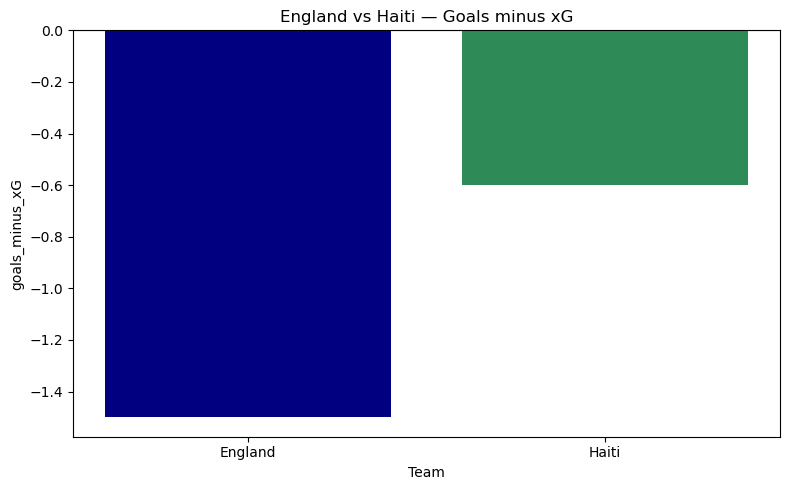

In [73]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


teams = ["England", "Haiti"]

goals_minus_xG = [
    match.loc[match["team"] == "England Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Haiti Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["navy", "seagreen"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("England vs Haiti — Goals minus xG")

plt.tight_layout()
plt.show()

Neither team scored as many goals as expected; however, given both teams' performances in the qualifiers and playoffs, one would have expected England to achieve a better result.

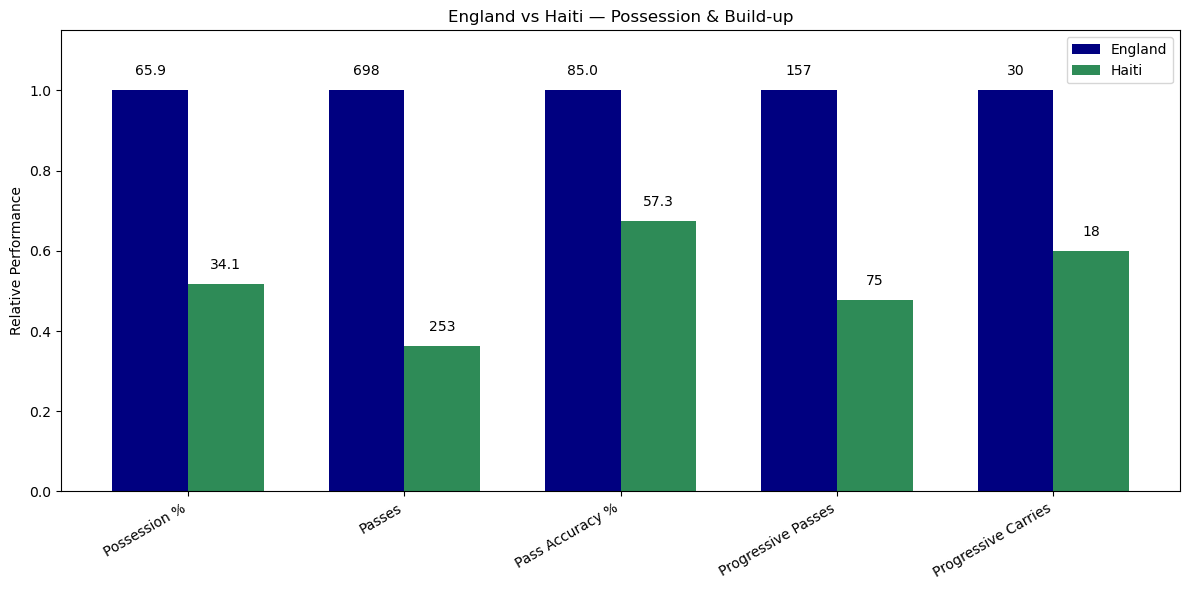

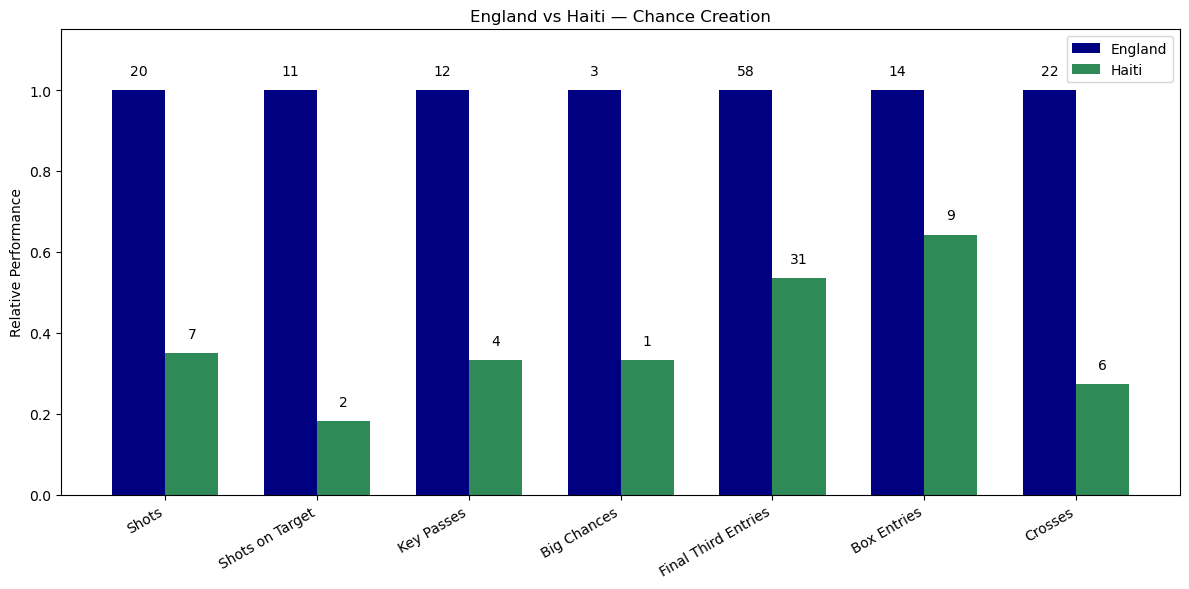

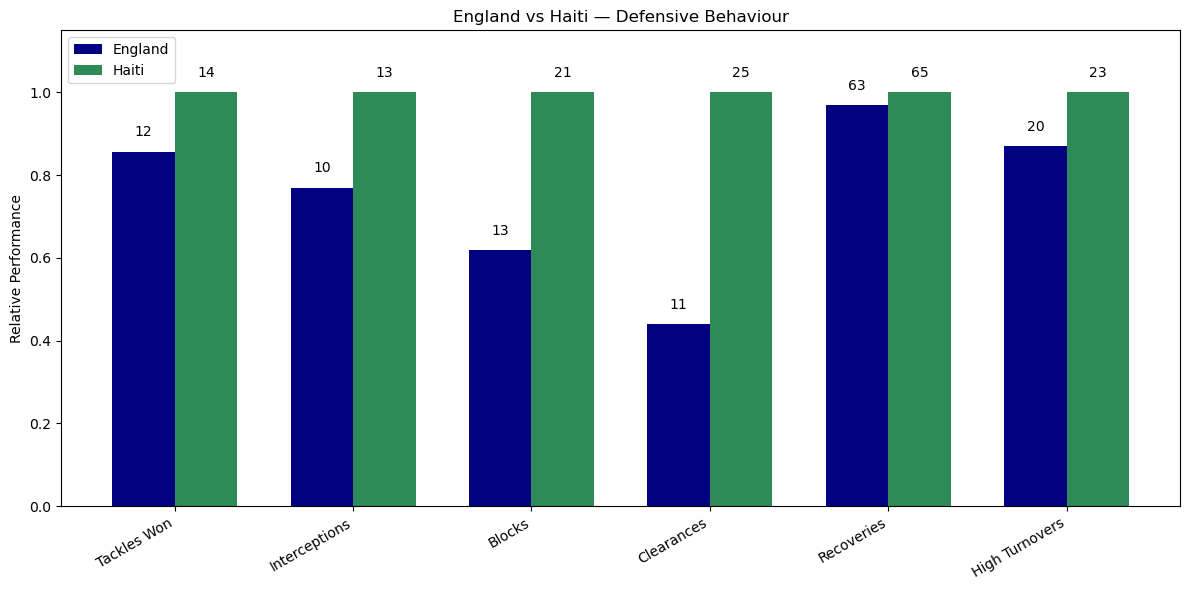

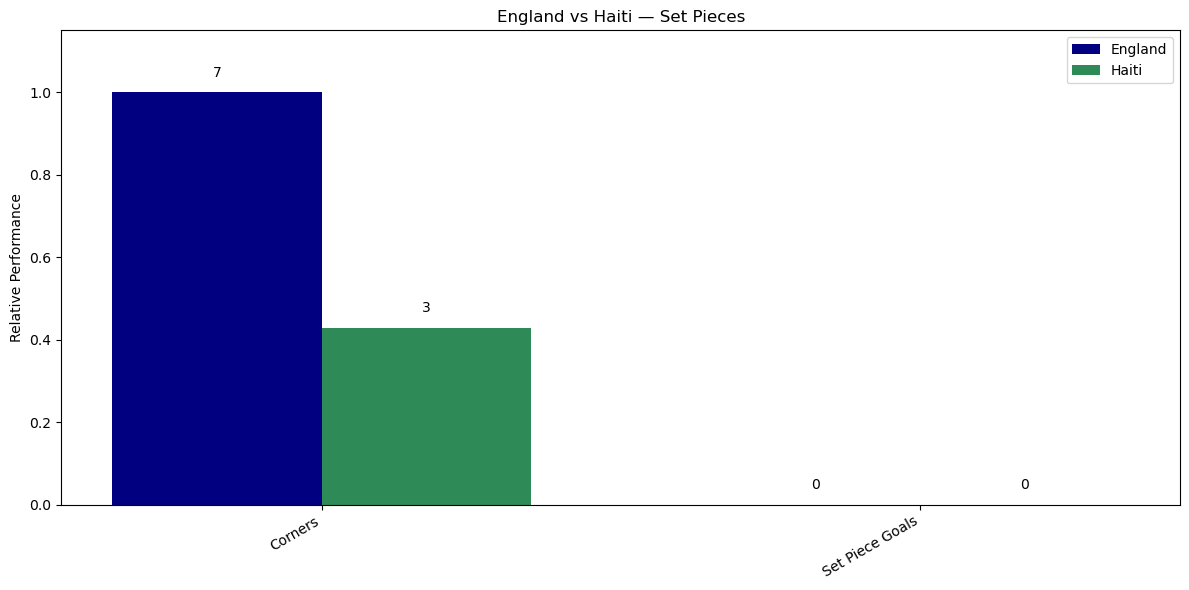

In [76]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "England": "England Women's",
    "Haiti": "Haiti Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    hai_values = np.array([
        match.loc[
            match["team"] == team_names["Haiti"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(eng_values, hai_values)

    # Normalize
    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )

    hai_normalized = np.divide(
        hai_values,
        max_values,
        out=np.zeros_like(hai_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_eng = plt.bar(
        x - width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )

    bars_hai = plt.bar(
        x + width / 2,
        hai_normalized,
        width,
        label="Haiti",
        color="seagreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_eng, eng_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_hai, hai_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"England vs Haiti — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion ENG-HAI

The statistics from the Haiti vs. England match show quite a disparity. Despite England’s victory, Haiti put up some **impressive numbers**, such as: 

- 11 shots on target, **10 of which were saved**;
- 21 blocks 
- 65 recoveries

In my view, there are two types of teams: <br>
<br>
A) those that know they are outmatched but fight until the end, regardless of whether their opponent is more skilled or not; <br>
B) and those that give up simply because they are weaker and adopt a defeatist attitude. <br>
<br>
In these statistics, Haiti showed the attitude of Team A.

# Analysis Denmark's Group Stage games

In [85]:
team = "Denmark Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
16,3893795,China PR Women's,Denmark Women's,Group
17,3893795,Denmark Women's,China PR Women's,Group
48,3893811,Denmark Women's,England Women's,Group
49,3893811,England Women's,Denmark Women's,Group
76,3893825,Denmark Women's,Haiti Women's,Group
77,3893825,Haiti Women's,Denmark Women's,Group


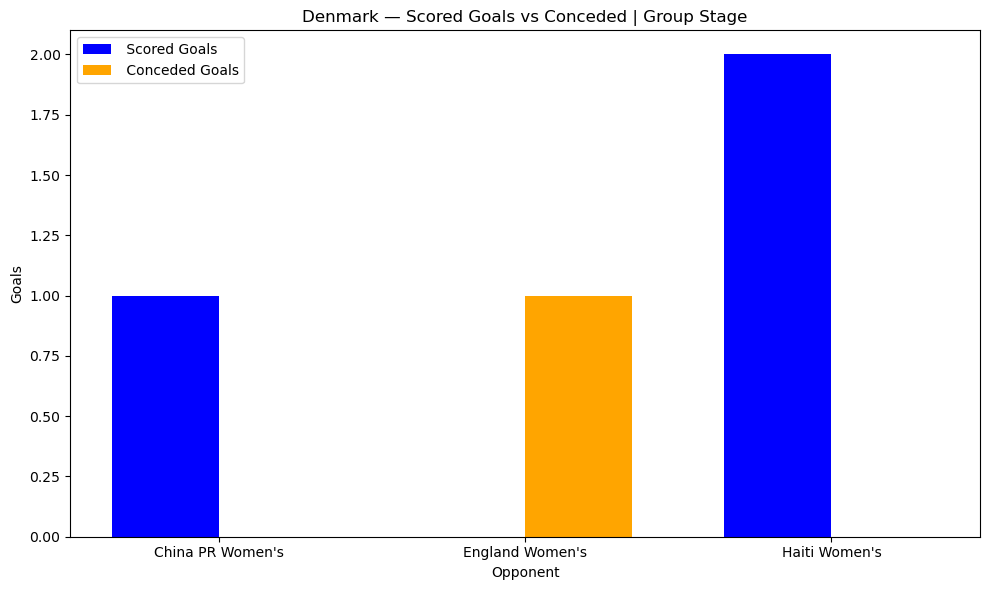

In [87]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Denmark Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Denmark — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Denmark won two games and lost one (against England). 

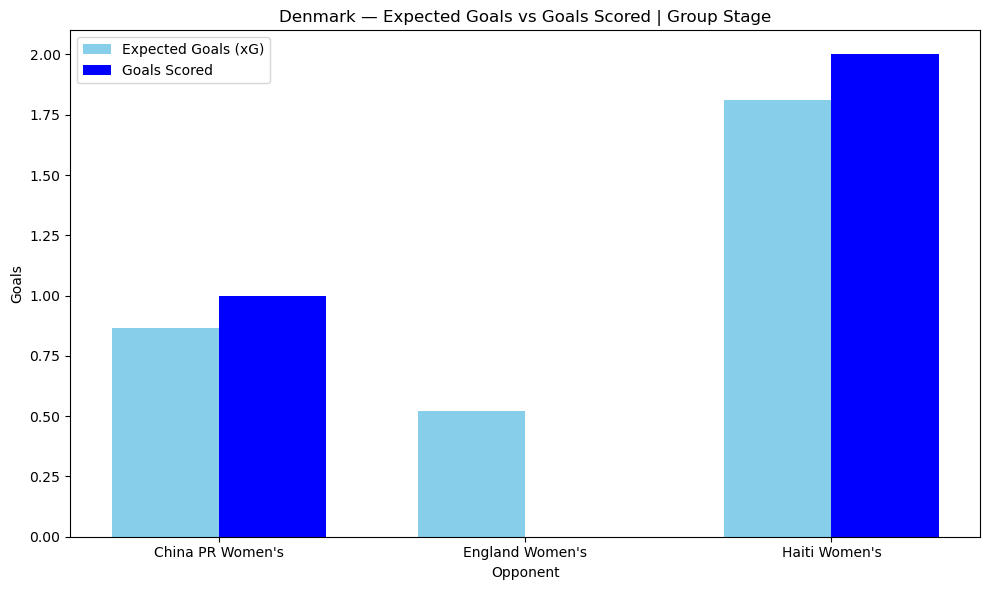

In [89]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Denmark Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Denmark — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Denmark almost always outperformed their xG, which showed they were more effective than expected.
However, against England, their xG was higher than their goals scored (they didn't score). 

# Analysis DEN-CHI

In [93]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Denmark": [
        match.loc[
            match["team"] == "Denmark Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "China": [
        match.loc[
            match["team"] == "China PR Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Denmark", "China"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Denmark", "China"]
].round(1)


# Display table

comparison

,Metric,Denmark,China
0,Goals,1.0,0.0
1,xG,0.9,0.3
2,Goals Minus xG,0.1,-0.3
3,Shots,13.0,8.0
4,Shots on Target,2.0,2.0
5,Saves,2.0,1.0
6,Possession %,59.9,40.1
7,Pass Accuracy %,74.6,70.7
8,Progressive Passes,131.0,101.0
9,Progressive Carries,18.0,14.0


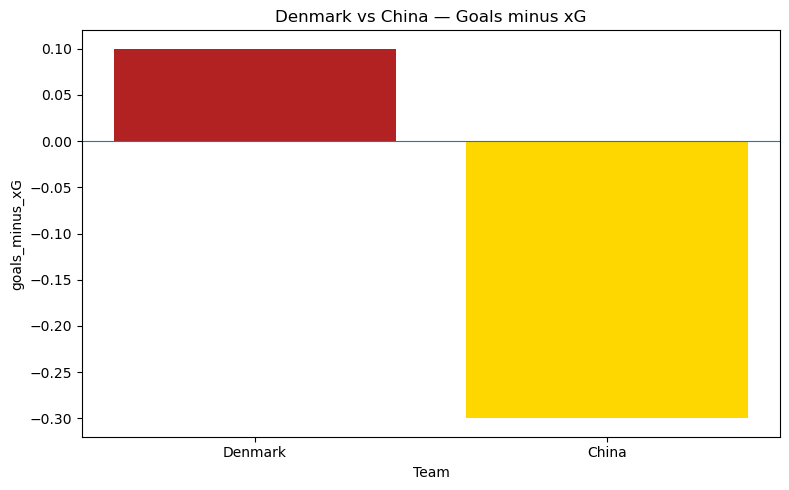

In [95]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()


teams = ["Denmark", "China"]

goals_minus_xG = [
    match.loc[match["team"] == "Denmark Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "China PR Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["firebrick", "gold"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Denmark vs China — Goals minus xG")

plt.tight_layout()
plt.show()

China fell short of expectations, failing to score a single goal. Denmark, on the other hand, with its lone goal, caused the graph to show a more positive *xG-minus-goals* performance.

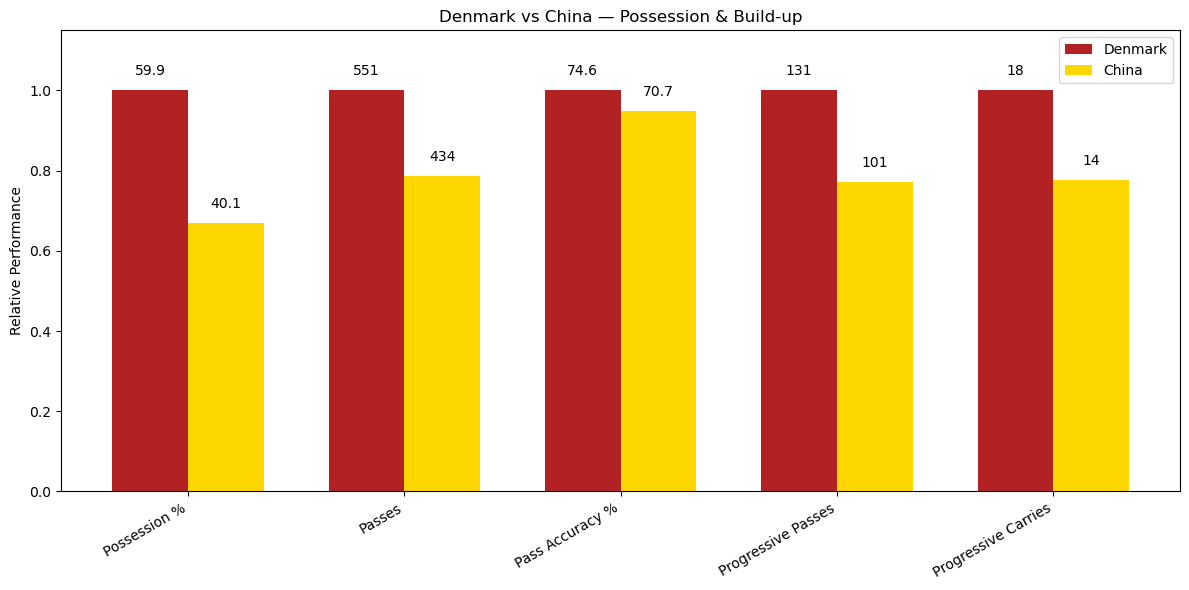

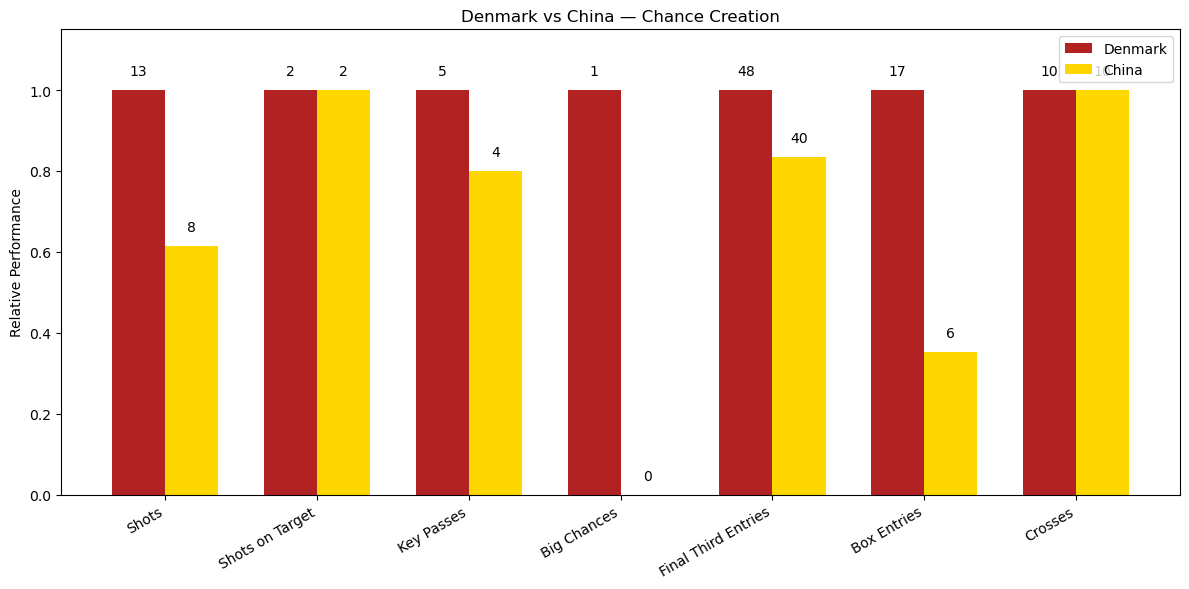

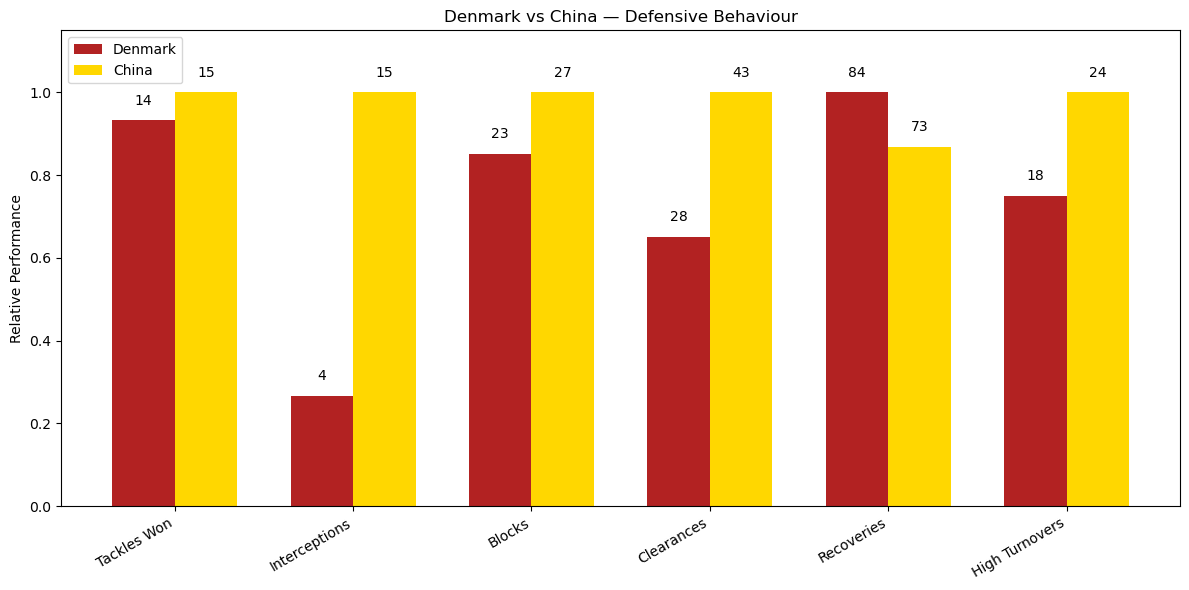

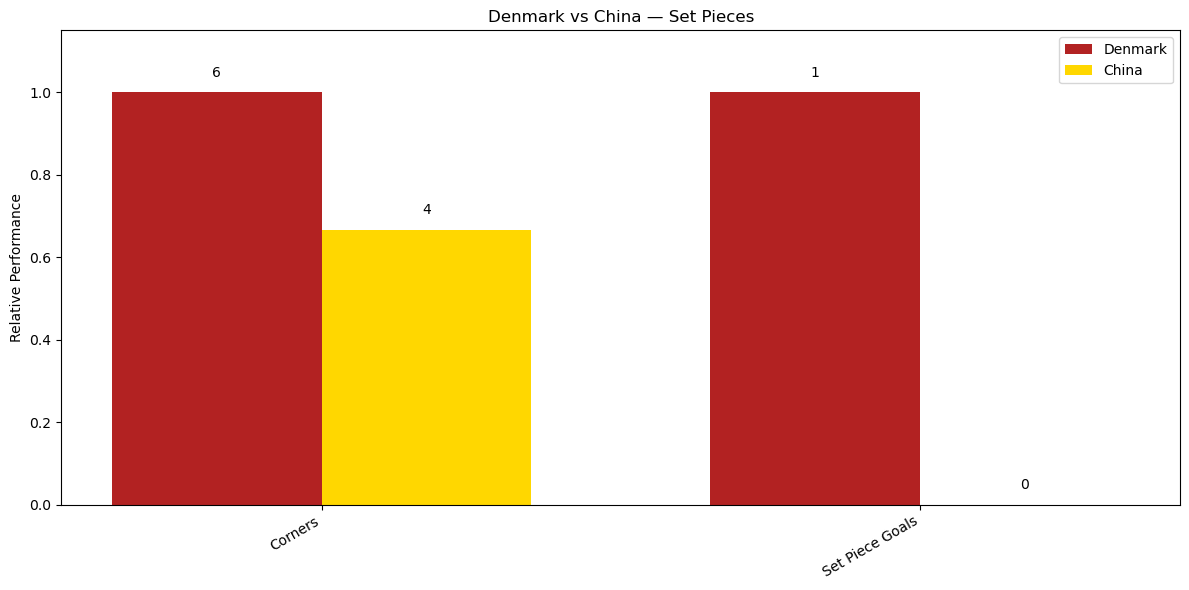

In [99]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Denmark": "Denmark Women's",
    "China": "China PR Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    den_values = np.array([
        match.loc[
            match["team"] == team_names["Denmark"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    chi_values = np.array([
        match.loc[
            match["team"] == team_names["China"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(den_values, chi_values)

    # Normalize
    den_normalized = np.divide(
        den_values,
        max_values,
        out=np.zeros_like(den_values),
        where=max_values != 0
    )

    chi_normalized = np.divide(
        chi_values,
        max_values,
        out=np.zeros_like(chi_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_den = plt.bar(
        x - width / 2,
        den_normalized,
        width,
        label="Denmark",
        color="firebrick"
    )

    bars_chi = plt.bar(
        x + width / 2,
        chi_normalized,
        width,
        label="China",
        color="gold"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_den, den_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_chi, chi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Denmark vs China — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion DEN-CHI

In this game, it was perfectly clear who played offensively (Denmark) and who played defensively (China). The performance metrics are quite similar, which suggests that the game was played fairly.

# Analysis of DEN-HAI

In [105]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Denmark": [
        match.loc[
            match["team"] == "Denmark Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Haiti": [
        match.loc[
            match["team"] == "Haiti Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Denmark", "Haiti"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Denmark", "Haiti"]
].round(1)


# Display table

comparison

,Metric,Denmark,Haiti
0,Goals,2.0,0.0
1,xG,1.8,0.5
2,Goals Minus xG,0.2,-0.5
3,Shots,9.0,9.0
4,Shots on Target,6.0,2.0
5,Saves,2.0,4.0
6,Possession %,56.2,43.8
7,Pass Accuracy %,73.8,57.6
8,Progressive Passes,139.0,107.0
9,Progressive Carries,26.0,17.0


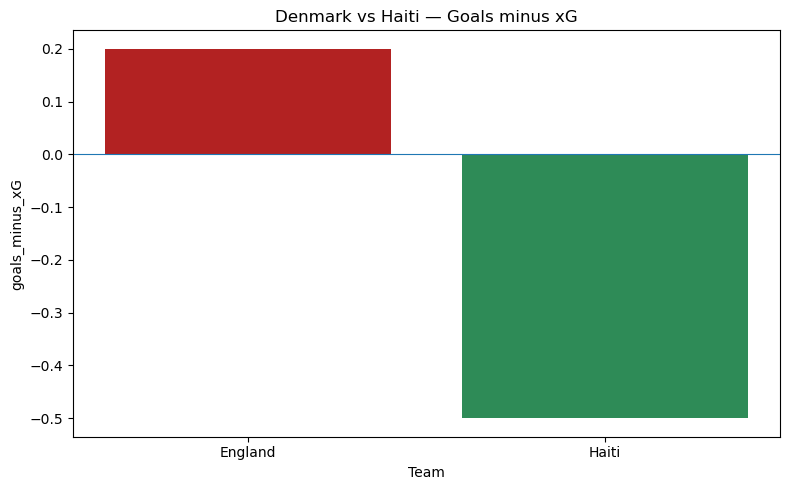

In [107]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()


teams = ["England", "Haiti"]

goals_minus_xG = [
    match.loc[match["team"] == "Denmark Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Haiti Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["firebrick", "seagreen"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Denmark vs Haiti — Goals minus xG")

plt.tight_layout()
plt.show()

With 2 goals from 1.8 xG, Denmark slightly exceeded the quality of chances created, showing good finishing efficiency. Nonetheless, Haiti underperformed by not scorring. 

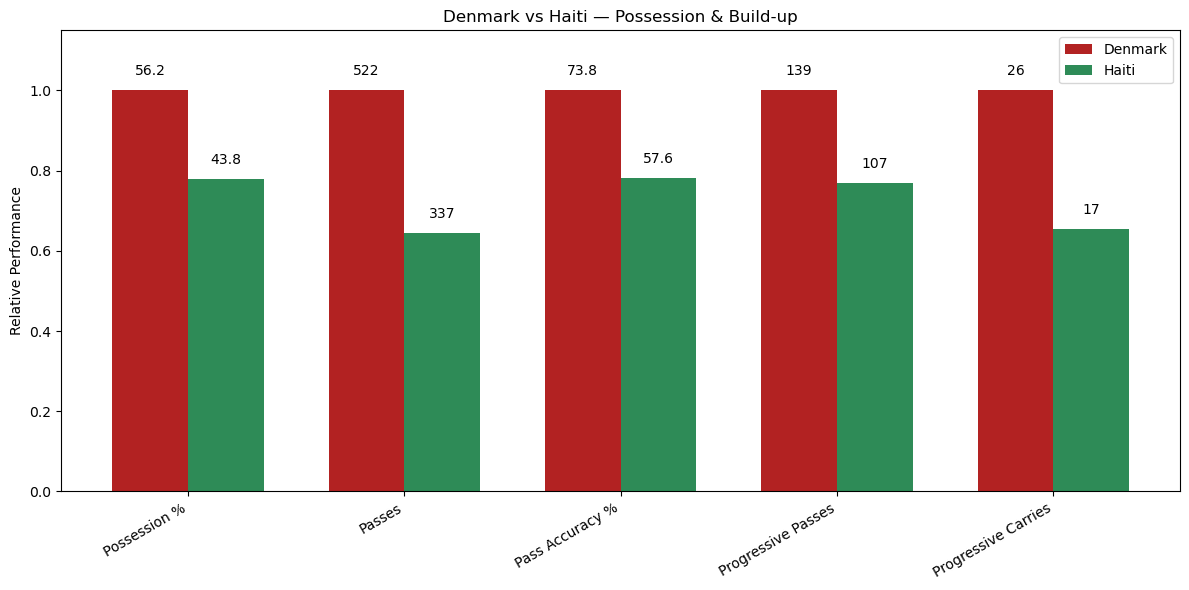

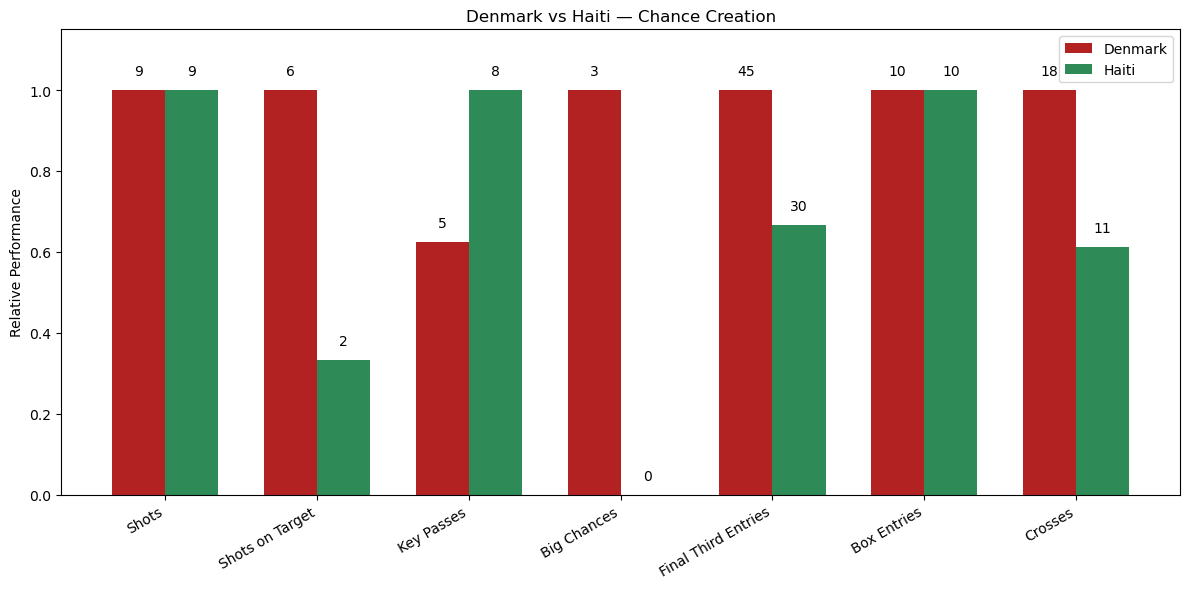

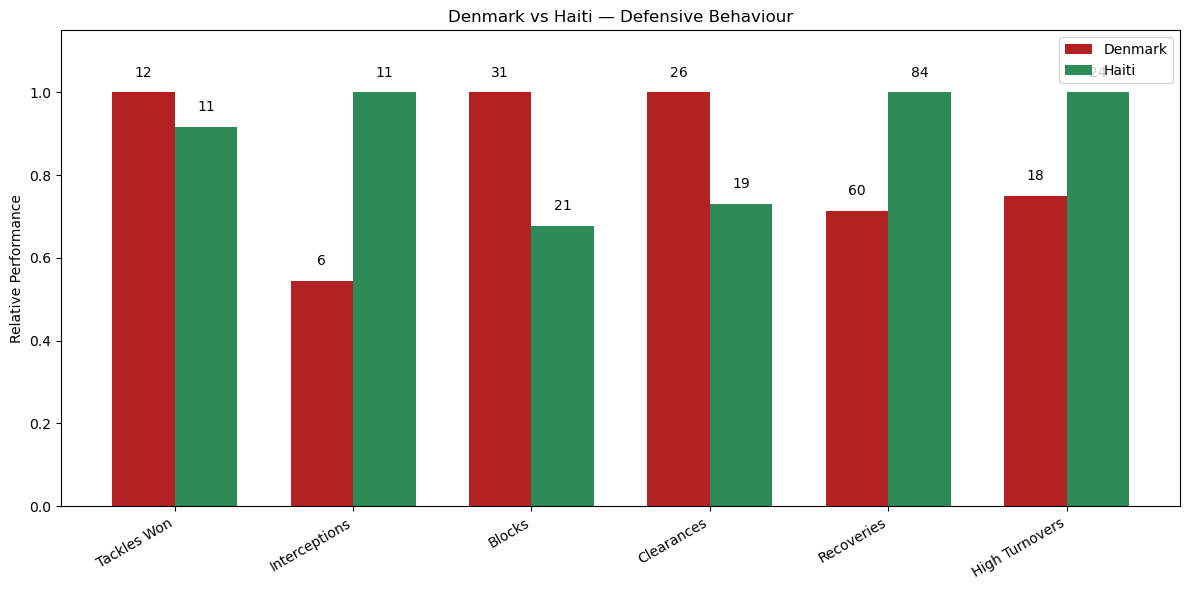

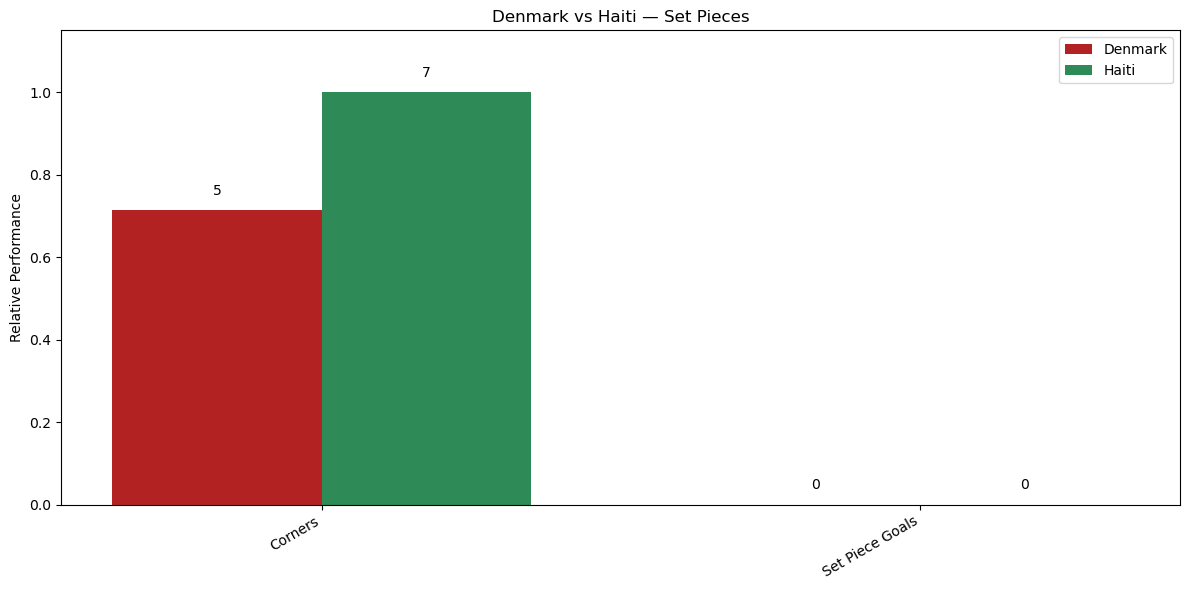

In [110]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Denmark Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "Denmark Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Denmark": "Denmark Women's",
    "Haiti": "Haiti Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    den_values = np.array([
        match.loc[
            match["team"] == team_names["Denmark"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    hai_values = np.array([
        match.loc[
            match["team"] == team_names["Haiti"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(den_values, hai_values)

    # Normalize
    den_normalized = np.divide(
        den_values,
        max_values,
        out=np.zeros_like(den_values),
        where=max_values != 0
    )

    hai_normalized = np.divide(
        hai_values,
        max_values,
        out=np.zeros_like(hai_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_den = plt.bar(
        x - width / 2,
        den_normalized,
        width,
        label="Denmark",
        color="firebrick"
    )

    bars_hai = plt.bar(
        x + width / 2,
        hai_normalized,
        width,
        label="Haiti",
        color="seagreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_den, den_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_hai, hai_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Denmark vs Haiti — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion DEN-HAI

Overall, Denmark played better than Haiti. But the Caribbean team, just as in the game against England, always tried to hold its own against the higher-ranked opponent.
Although there are statistics that show Denmark’s dominance over Haiti, Haiti also deserves credit for managing to keep the game so close.

# Analysis China's Group Stage games

In [120]:
team = "China PR Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
16,3893795,China PR Women's,Denmark Women's,Group
17,3893795,Denmark Women's,China PR Women's,Group
52,3893813,China PR Women's,Haiti Women's,Group
53,3893813,Haiti Women's,China PR Women's,Group
82,3893828,China PR Women's,England Women's,Group
83,3893828,England Women's,China PR Women's,Group


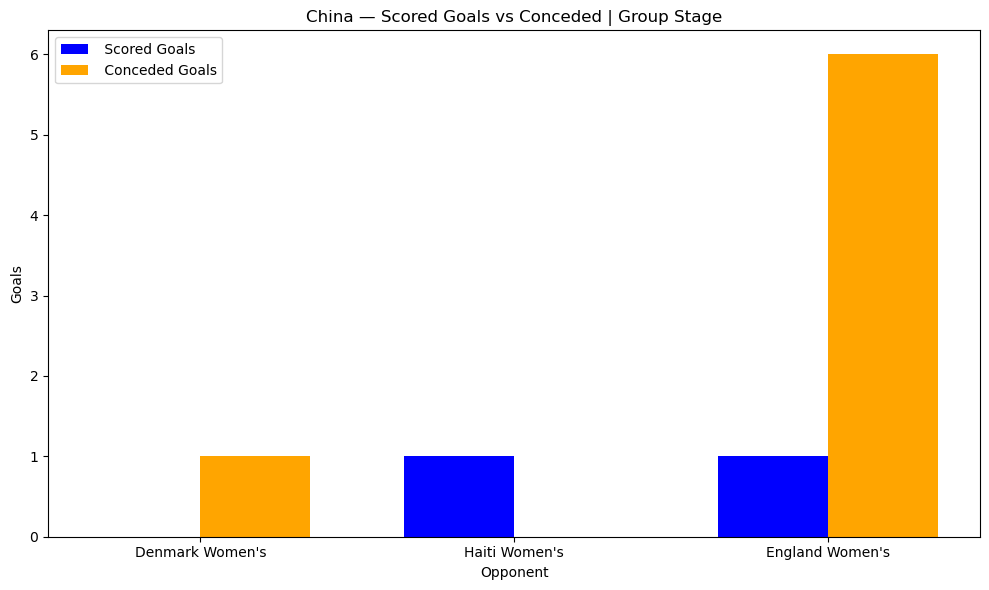

In [122]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "China PR Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("China — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

China lost two games and won one game (agaist Haiti).

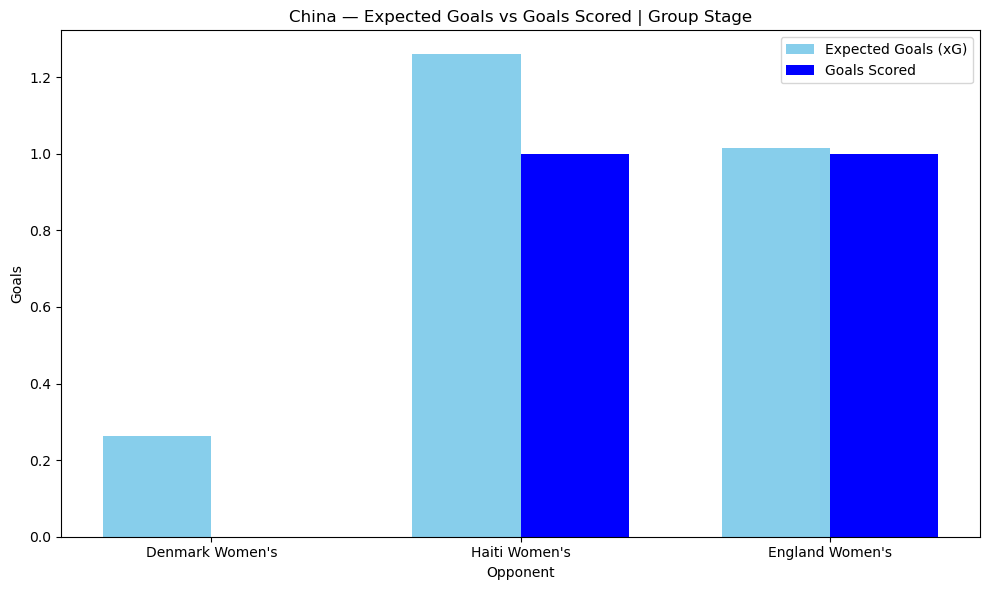

In [124]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "China PR Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("China — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

China underperformed the xG in the three games played in the Group Stage. This might explain a lack of effectiveness or finalization.

# Analysis of CHI-HAI

In [129]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "China": [
        match.loc[
            match["team"] == "China PR Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Haiti": [
        match.loc[
            match["team"] == "Haiti Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["China", "Haiti"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["China", "Haiti"]
].round(1)


# Display table

comparison

,Metric,China,Haiti
0,Goals,1.0,0.0
1,xG,1.3,0.8
2,Goals Minus xG,-0.3,-0.8
3,Shots,8.0,7.0
4,Shots on Target,3.0,1.0
5,Saves,1.0,3.0
6,Possession %,46.8,53.2
7,Pass Accuracy %,77.9,69.5
8,Progressive Passes,115.0,114.0
9,Progressive Carries,19.0,19.0


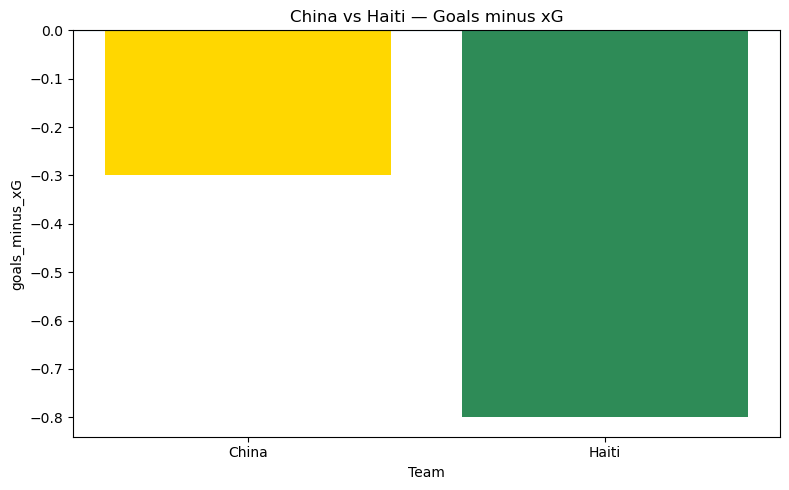

In [131]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    )
].copy()


teams = ["China", "Haiti"]

goals_minus_xG = [
    match.loc[match["team"] == "China PR Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Haiti Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["gold", "seagreen"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("China vs Haiti — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams underperformed in comparison to the xG. Haiti a bigger value, and might explain a lack of shot accuracy. 

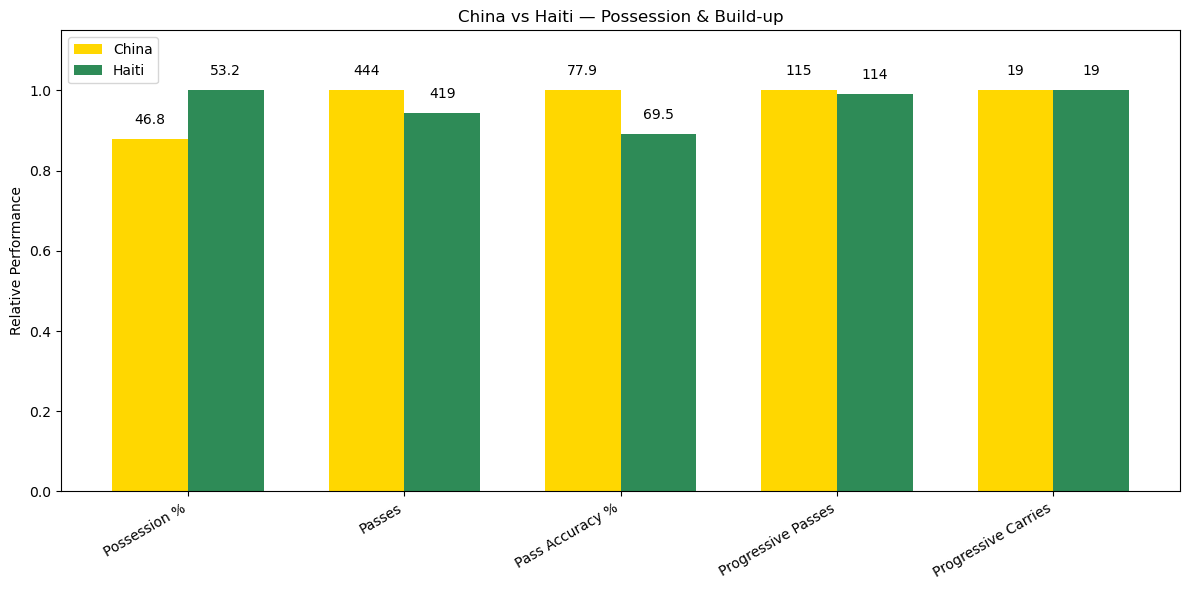

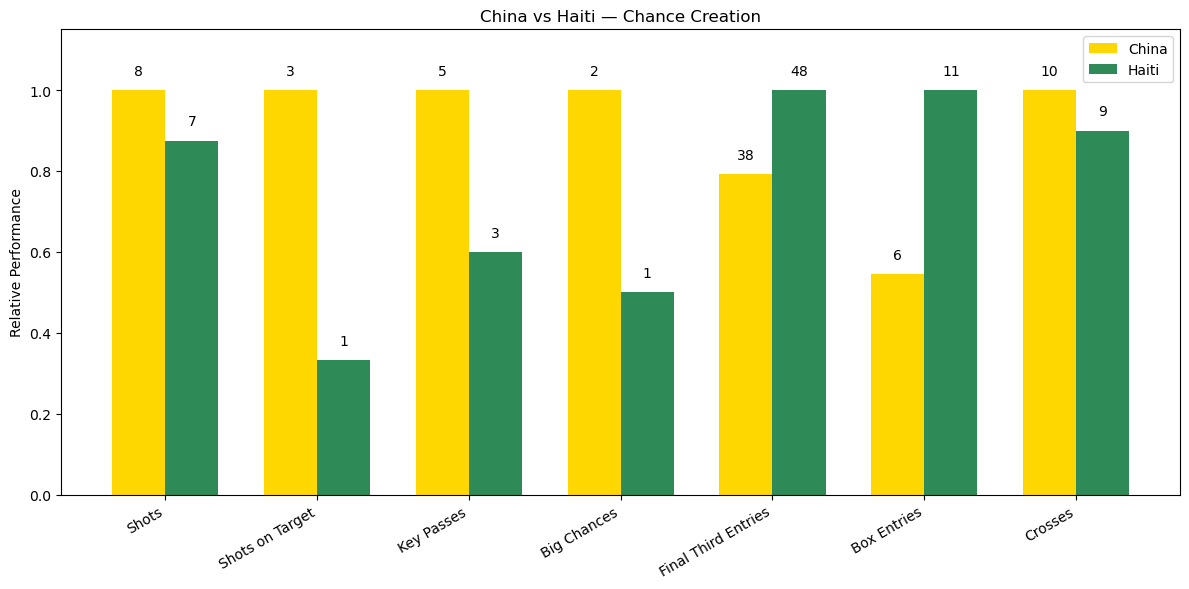

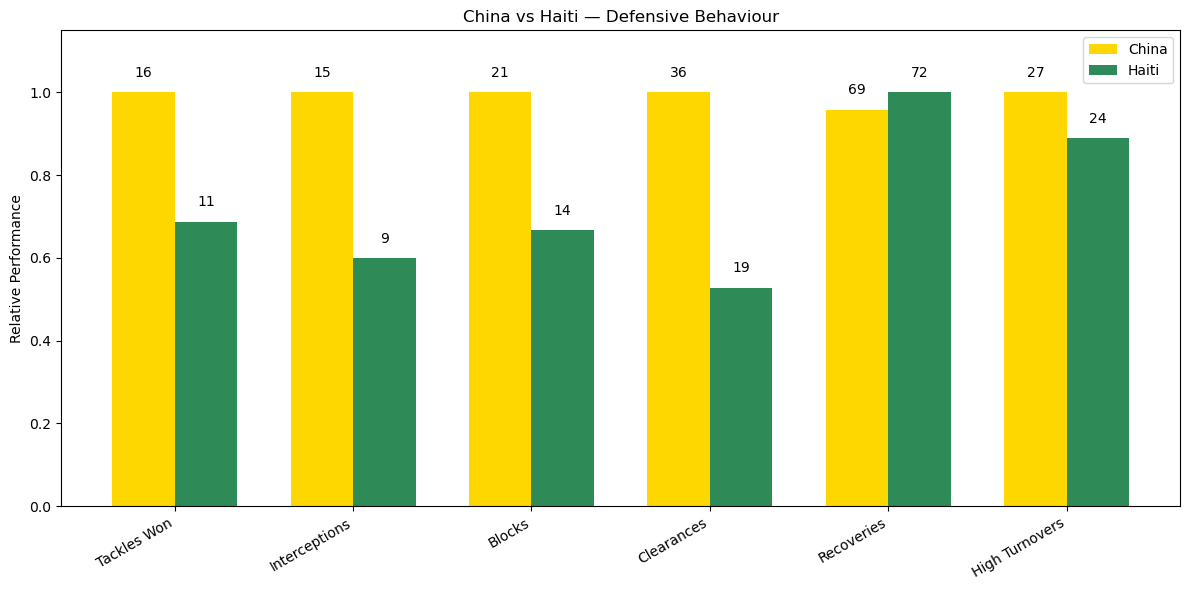

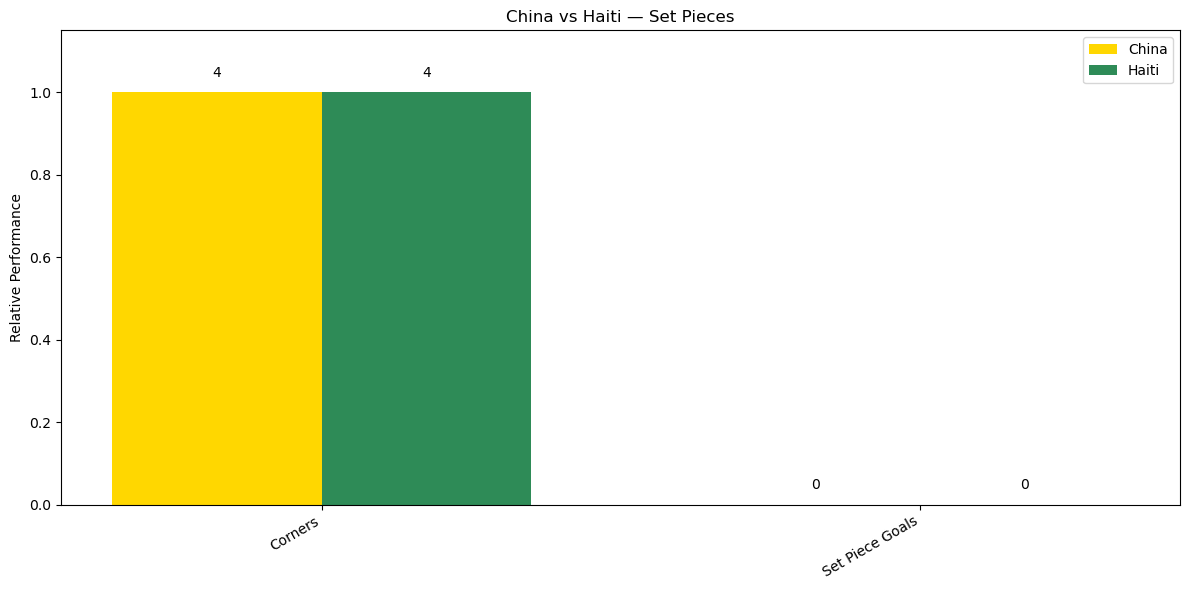

In [135]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "China PR Women's") &
        (womens_world_cup_stats["opponent"] == "Haiti Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Haiti Women's") &
        (womens_world_cup_stats["opponent"] == "China PR Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "China": "China PR Women's",
    "Haiti": "Haiti Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    chi_values = np.array([
        match.loc[
            match["team"] == team_names["China"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    hai_values = np.array([
        match.loc[
            match["team"] == team_names["Haiti"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(chi_values, hai_values)

    # Normalize
    chi_normalized = np.divide(
        chi_values,
        max_values,
        out=np.zeros_like(chi_values),
        where=max_values != 0
    )

    hai_normalized = np.divide(
        hai_values,
        max_values,
        out=np.zeros_like(hai_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_chi = plt.bar(
        x - width / 2,
        chi_normalized,
        width,
        label="China",
        color="gold"
    )

    bars_hai = plt.bar(
        x + width / 2,
        hai_normalized,
        width,
        label="Haiti",
        color="seagreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_chi, chi_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_hai, hai_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"China vs Haiti — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion CHI-HAI

In this game, China narrowly led in almost all metrics on the relative performance charts. This reflects the fact that, although the game was fairly even (which may cause some confusion when viewing the charts, since the variables are normalized and the scale may appear larger than it actually is), China was more effective on defense, in ball possession, and especially in creating scoring opportunities.

# Analysis Haiti's Group Stage games

In [140]:
team = "Haiti Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
14,3893794,England Women's,Haiti Women's,Group
15,3893794,Haiti Women's,England Women's,Group
52,3893813,China PR Women's,Haiti Women's,Group
53,3893813,Haiti Women's,China PR Women's,Group
76,3893825,Denmark Women's,Haiti Women's,Group
77,3893825,Haiti Women's,Denmark Women's,Group


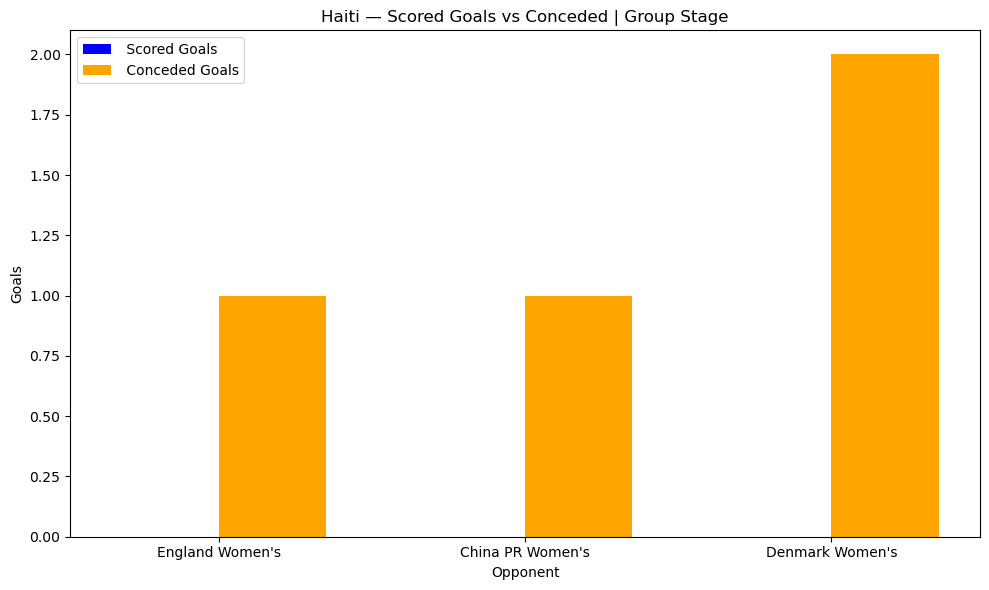

In [142]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Haiti Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Haiti — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Haiti lost all the games of the Group Stage.

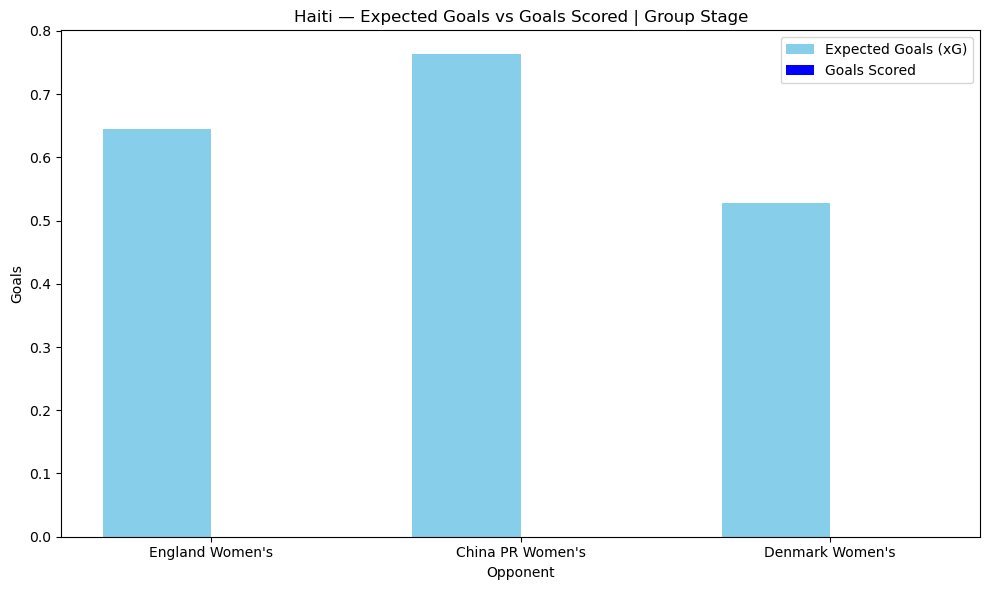

In [144]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Haiti Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Haiti — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Haiti underperformed in light of the xG in all games

# Final Conclusion Group D

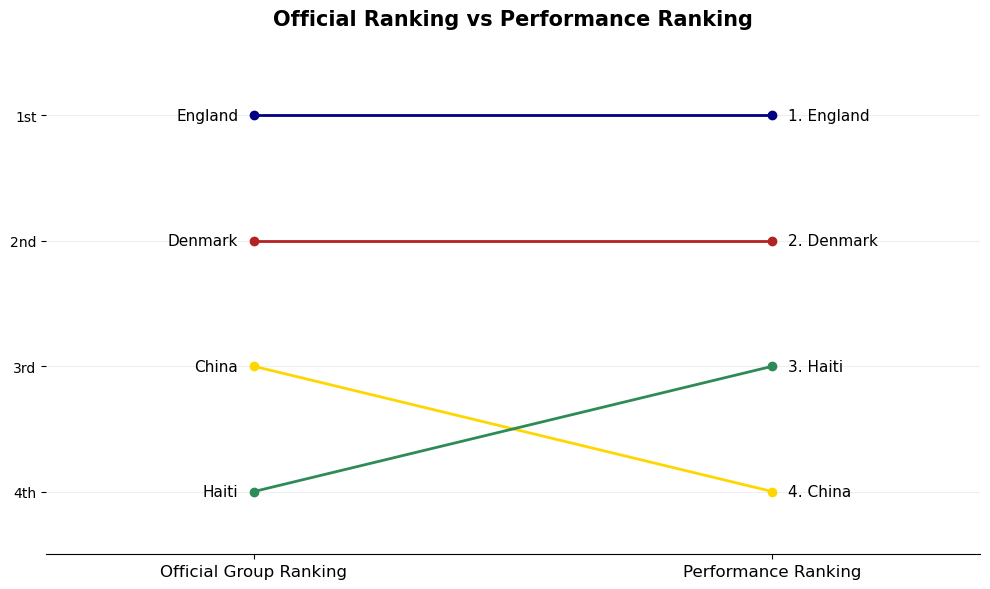

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["England", "Denmark", "China", "Haiti"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 2, 4, 3]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "England": "navy",
    "Denmark": "firebrick",
    "China": "gold",
    "Haiti": "seagreen"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

While analyzing the Group D matches in the group stage, I singled out two teams:

- England, for its overwhelming performance against the other teams, and 
- Haiti, which, despite losing all three games, always held its own against the teams it faced. 
The number of saves against England’s attack is unbelievable (11 shots, 10 saves), as is the fact that they consistently managed to keep pace with their opponent’s rhythm.

Denmark earned second place in fine style, with evenly matched games and better performances than expected from the Scandinavian team. China took 4th place in terms of performance relative to their showing in nearly every game. Although they scored goals (Haiti did not), they consistently posted a negative xG. 